In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:

df = pd.read_csv('lmsys-chatbot-arena/train.csv')
print(f"Shape of dataset: {df.shape}")

Shape of dataset: (57477, 9)


In [3]:
df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57477 non-null  int64 
 1   model_a         57477 non-null  object
 2   model_b         57477 non-null  object
 3   prompt          57477 non-null  object
 4   response_a      57477 non-null  object
 5   response_b      57477 non-null  object
 6   winner_model_a  57477 non-null  int64 
 7   winner_model_b  57477 non-null  int64 
 8   winner_tie      57477 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.9+ MB


In [5]:
df.dtypes

id                 int64
model_a           object
model_b           object
prompt            object
response_a        object
response_b        object
winner_model_a     int64
winner_model_b     int64
winner_tie         int64
dtype: object

In [6]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values/len(df))*100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [7]:
#SO no missing values

In [8]:
print(f"Number of unique models in position A: {df['model_a'].nunique()}")
print(f"Number of unique models in position B: {df['model_b'].nunique()}")
print(f"Total unique models overall: {len(set(df['model_a'].unique()) | set(df['model_b'].unique()))}")

Number of unique models in position A: 64
Number of unique models in position B: 64
Total unique models overall: 64


In [9]:
set(df['model_a'].unique()) == set(df['model_b'].unique())

True

In [10]:
pd.set_option('display.max_rows', None)


In [11]:
model_a_freq = df['model_a'].value_counts()
model_b_freq = df['model_b'].value_counts()

all_models = pd.concat([df['model_a'], df['model_b']])
model_overall_freq = all_models.value_counts()

print(model_overall_freq)

gpt-4-1106-preview                7387
gpt-3.5-turbo-0613                7083
gpt-4-0613                        6165
claude-2.1                        5583
claude-instant-1                  4136
gpt-4-0314                        4122
claude-1                          3978
vicuna-33b                        3720
mixtral-8x7b-instruct-v0.1        3545
vicuna-13b                        3448
llama-2-70b-chat                  3428
gpt-3.5-turbo-1106                3352
mistral-medium                    3315
llama-2-13b-chat                  2607
claude-2.0                        2456
zephyr-7b-beta                    2401
palm-2                            1977
llama-2-7b-chat                   1793
wizardlm-70b                      1644
openchat-3.5                      1632
mistral-7b-instruct               1617
koala-13b                         1598
vicuna-7b                         1591
wizardlm-13b                      1580
oasst-pythia-12b                  1494
gemini-pro-dev-api       

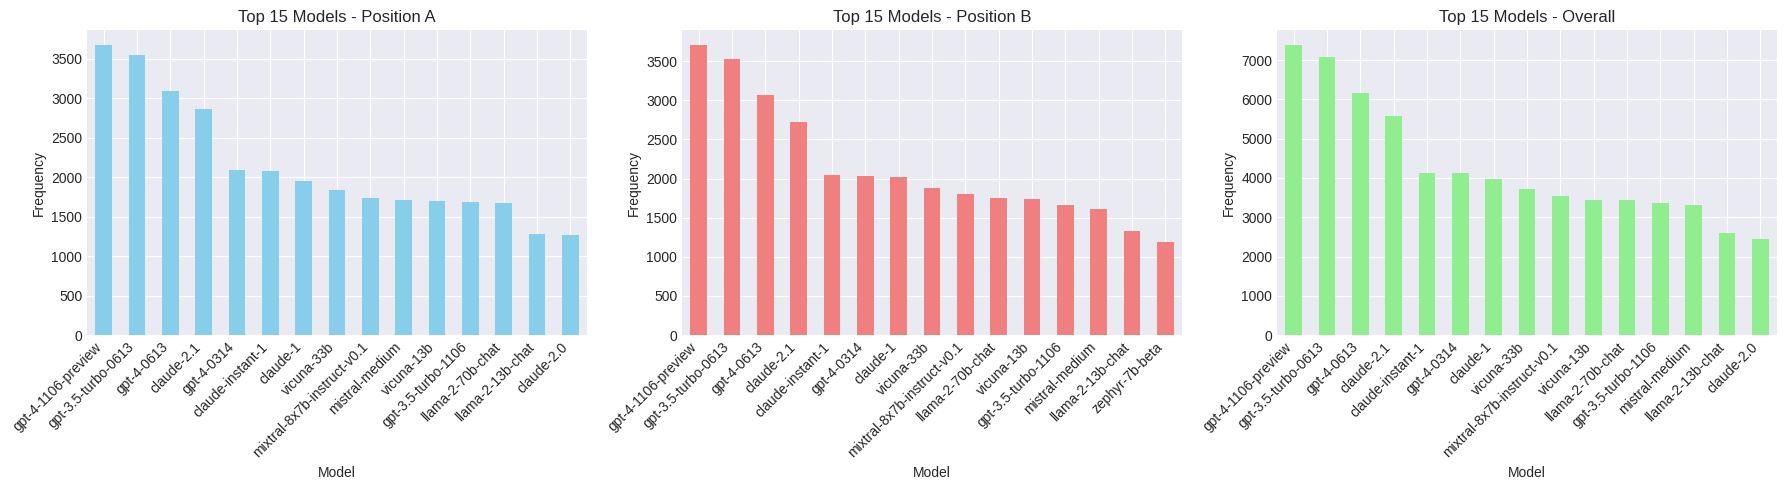

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_a_freq.head(15).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 15 Models - Position A')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

model_b_freq.head(15).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 15 Models - Position B')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

model_overall_freq.head(15).plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Top 15 Models - Overall')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Frequency')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

In [13]:
df['model_pair'] = df['model_a'] + ' vs ' + df['model_b']
pair_counts = df['model_pair'].value_counts()

print(f"Number of unique model pairs: {len(pair_counts)}")
print(pair_counts)

Number of unique model pairs: 2454
model_pair
claude-2.1 vs gpt-4-1106-preview                                557
gpt-4-1106-preview vs claude-2.1                                516
gpt-4-1106-preview vs gpt-4-0613                                502
gpt-4-0613 vs gpt-4-1106-preview                                480
claude-2.1 vs claude-1                                          412
claude-2.1 vs gpt-4-0613                                        392
gpt-3.5-turbo-0613 vs gpt-4-1106-preview                        370
gpt-4-0613 vs claude-2.1                                        366
claude-1 vs claude-2.1                                          351
gpt-4-1106-preview vs gpt-3.5-turbo-0613                        337
gpt-4-0613 vs gpt-4-0314                                        290
gpt-3.5-turbo-1106 vs gpt-4-1106-preview                        289
gpt-4-1106-preview vs gpt-3.5-turbo-1106                        287
gpt-4-0314 vs gpt-4-0613                                        270
gp

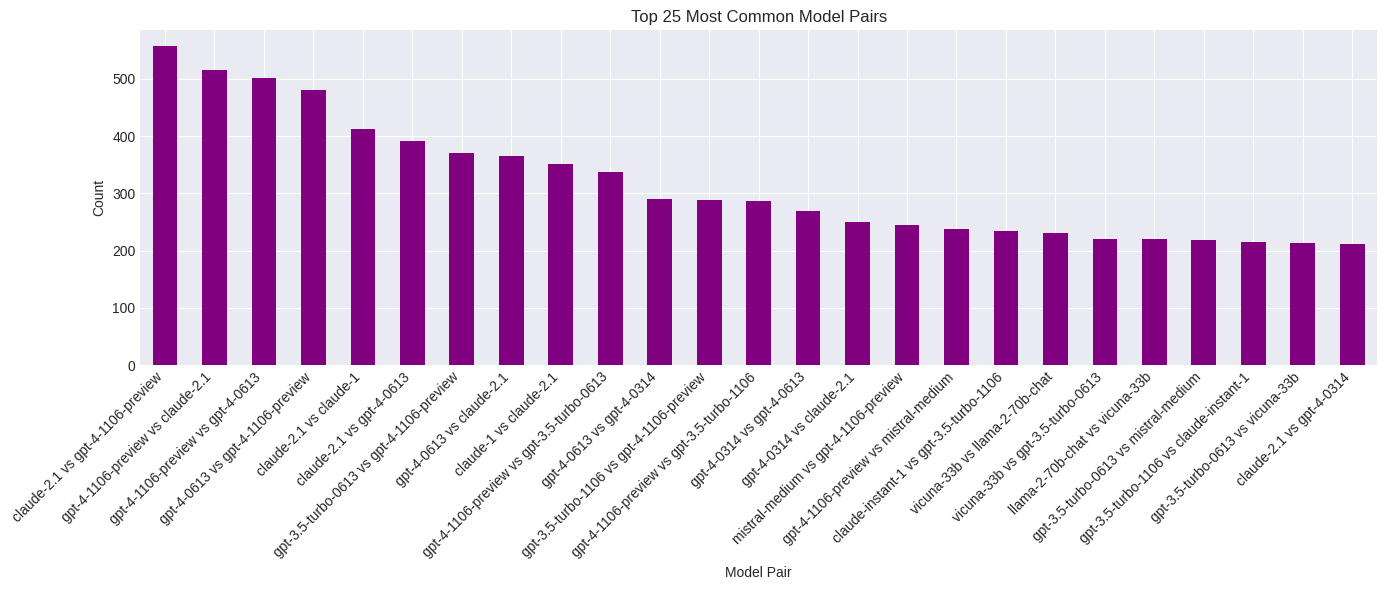

In [14]:
plt.figure(figsize=(14, 6))
pair_counts.head(25).plot(kind='bar', color='purple')
plt.title('Top 25 Most Common Model Pairs')
plt.xlabel('Model Pair')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# AS you see there is a problem here, as for example the "claude-2.1 vs gpt-4-1106-preview" and the "gpt-4-1106-preview vs claude-2.1" are the same things, so we have to add their counts

In [16]:
df['unordered_pair'] = df.apply(lambda row: ' vs '.join(sorted([row['model_a'], row['model_b']])), axis=1)

unordered_counts = df['unordered_pair'].value_counts()

print(f"Number of unique unordered model pairs: {len(unordered_counts)}")
print(unordered_counts)

Number of unique unordered model pairs: 1275
unordered_pair
claude-2.1 vs gpt-4-1106-preview                                1073
gpt-4-0613 vs gpt-4-1106-preview                                 982
claude-1 vs claude-2.1                                           763
claude-2.1 vs gpt-4-0613                                         758
gpt-3.5-turbo-0613 vs gpt-4-1106-preview                         707
gpt-3.5-turbo-1106 vs gpt-4-1106-preview                         576
gpt-4-0314 vs gpt-4-0613                                         560
gpt-4-1106-preview vs mistral-medium                             482
claude-2.1 vs gpt-4-0314                                         462
llama-2-70b-chat vs vicuna-33b                                   451
claude-instant-1 vs gpt-3.5-turbo-1106                           451
gpt-3.5-turbo-0613 vs vicuna-33b                                 433
gpt-3.5-turbo-0613 vs mistral-medium                             405
gpt-4-1106-preview vs mixtral-8x7b-instruct

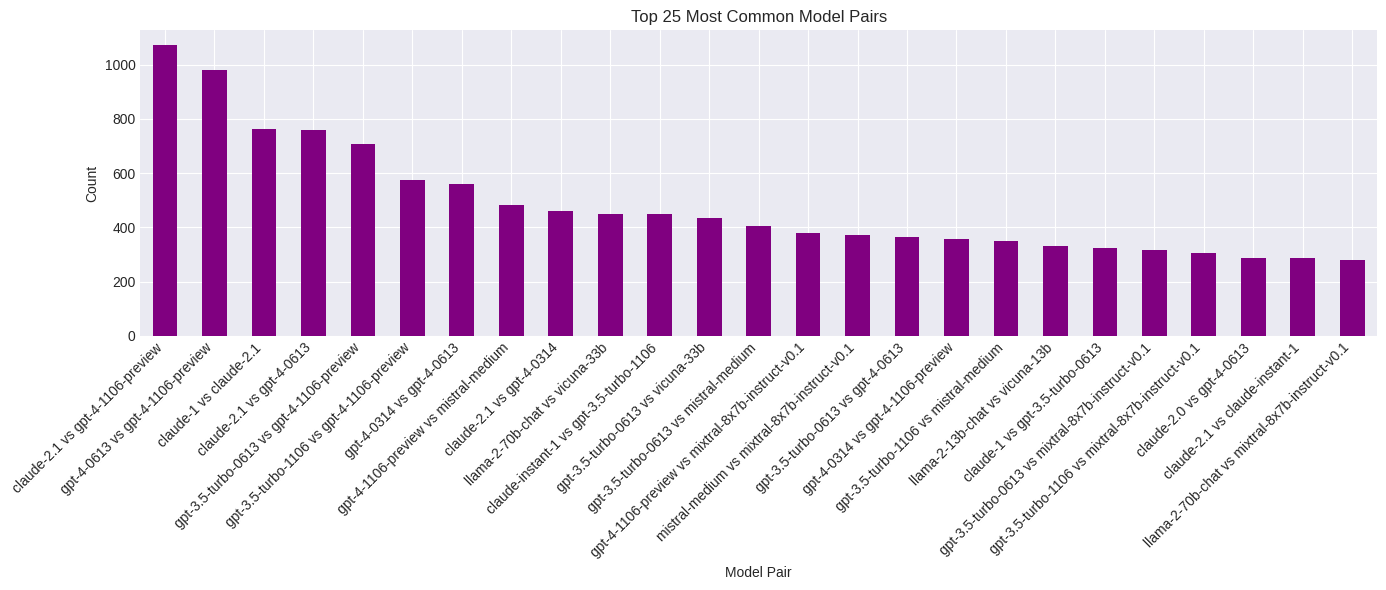

In [17]:
plt.figure(figsize=(14, 6))
unordered_counts.head(25).plot(kind='bar', color='purple')
plt.title('Top 25 Most Common Model Pairs')
plt.xlabel('Model Pair')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

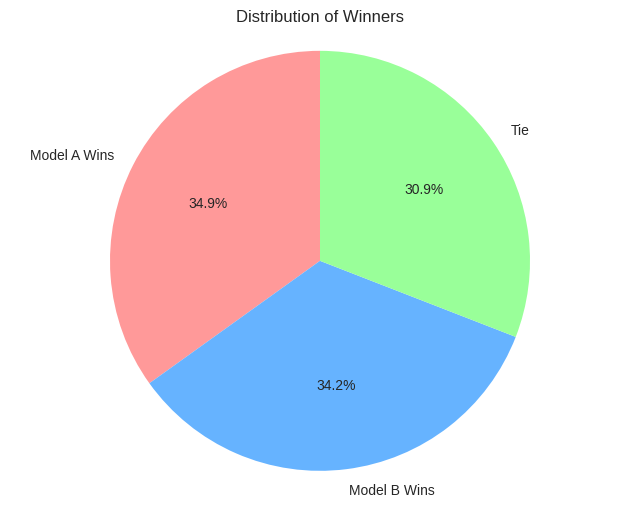

Winner distribution:
winner_model_a: 20064 (34.91%)
winner_model_b: 19652 (34.19%)
winner_tie: 17761 (30.90%)


In [18]:
winner_cols = ['winner_model_a', 'winner_model_b', 'winner_tie']
winner_counts = df[winner_cols].sum()

plt.figure(figsize=(8, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(winner_counts, labels=['Model A Wins', 'Model B Wins', 'Tie'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribution of Winners')
plt.axis('equal')
plt.show()

print("Winner distribution:")
for col, count in zip(winner_cols, winner_counts):
    print(f"{col}: {count} ({count/len(df)*100:.2f}%)")

# My intention was just to make sure that the position didn’t influence the results.

In [19]:
model_a_wins = df.groupby('model_a')['winner_model_a'].agg(['mean', 'count']).sort_values('mean', ascending=False)
model_a_wins.columns = ['win_rate_a', 'appearances_a']

model_b_wins = df.groupby('model_b')['winner_model_b'].agg(['mean', 'count']).sort_values('mean', ascending=False)
model_b_wins.columns = ['win_rate_b', 'appearances_b']

model_ties = pd.DataFrame()
model_ties['tie_rate_a'] = df.groupby('model_a')['winner_tie'].mean()
model_ties['tie_rate_b'] = df.groupby('model_b')['winner_tie'].mean()
model_ties['tie_rate_avg'] = (model_ties['tie_rate_a'] + model_ties['tie_rate_b']) / 2

print("Top 10 Models by Win Rate (when in Position A):")
print(model_a_wins[model_a_wins['appearances_a'] >= 10].head(10))
print("\nTop 10 Models by Win Rate (when in Position B):")
print(model_b_wins[model_b_wins['appearances_b'] >= 10].head(10))

print(model_ties.sort_values('tie_rate_avg', ascending=False).head(10))

Top 10 Models by Win Rate (when in Position A):
                    win_rate_a  appearances_a
model_a                                      
gpt-3.5-turbo-0314    0.568111            646
gpt-4-1106-preview    0.548940           3678
gpt-4-0125-preview    0.525573            567
gpt-4-0314            0.494969           2087
claude-1              0.443478           1955
qwen1.5-72b-chat      0.420863            278
gpt-4-0613            0.413036           3099
claude-2.0            0.399371           1272
claude-instant-1      0.397122           2085
mistral-medium        0.372802           1706

Top 10 Models by Win Rate (when in Position B):
                    win_rate_b  appearances_b
model_b                                      
gpt-4-1106-preview    0.553788           3709
gpt-3.5-turbo-0314    0.524390            656
gpt-4-0125-preview    0.502530            593
gpt-4-0314            0.471744           2035
claude-1              0.434998           2023
claude-instant-1      0.39688

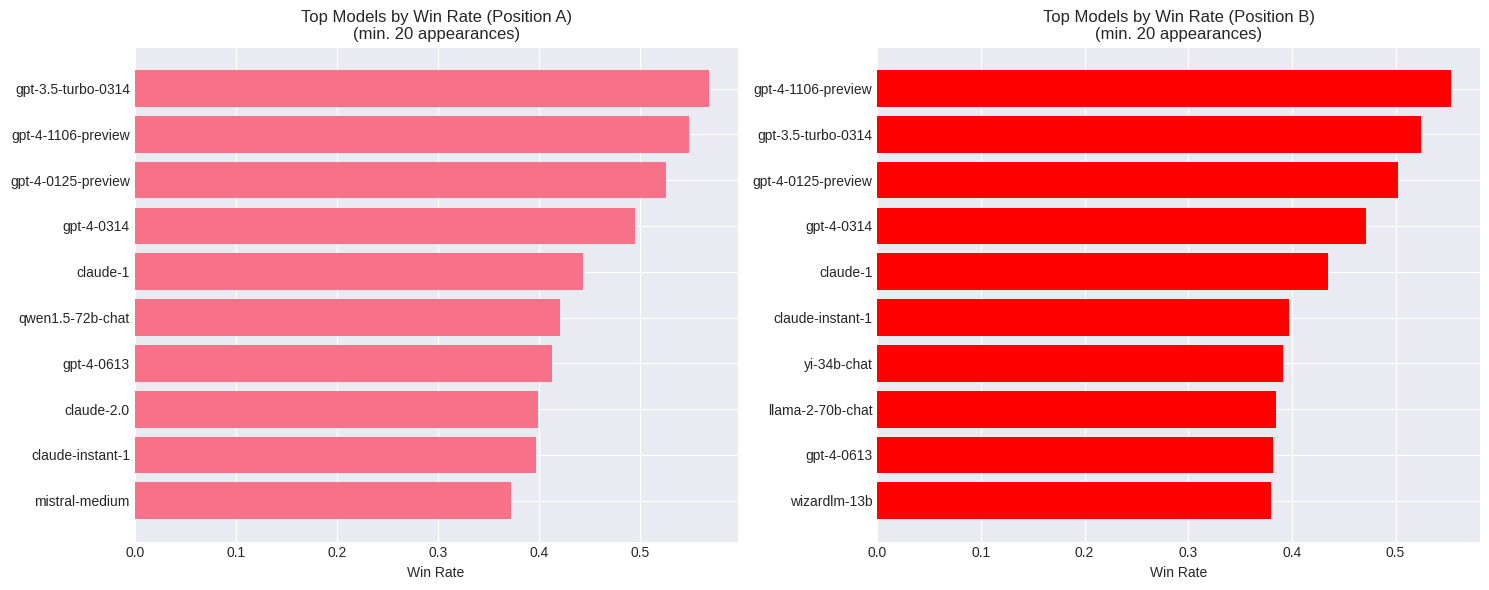

In [20]:
min_appearances = 20
top_models_a = model_a_wins[model_a_wins['appearances_a'] >= min_appearances].head(10)
top_models_b = model_b_wins[model_b_wins['appearances_b'] >= min_appearances].head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(range(len(top_models_a)), top_models_a['win_rate_a'].values)
axes[0].set_yticks(range(len(top_models_a)))
axes[0].set_yticklabels(top_models_a.index)
axes[0].set_xlabel('Win Rate')
axes[0].set_title(f'Top Models by Win Rate (Position A)\n(min. {min_appearances} appearances)')
axes[0].invert_yaxis()

axes[1].barh(range(len(top_models_b)), top_models_b['win_rate_b'].values, color='red')
axes[1].set_yticks(range(len(top_models_b)))
axes[1].set_yticklabels(top_models_b.index)
axes[1].set_xlabel('Win Rate')
axes[1].set_title(f'Top Models by Win Rate (Position B)\n(min. {min_appearances} appearances)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
df['prompt_length'] = df['prompt'].str.len()
df['response_a_length'] = df['response_a'].str.len()
df['response_b_length'] = df['response_b'].str.len()
df['length_diff'] = abs(df['response_a_length'] - df['response_b_length'])

model_response_stats = []

for model in model_overall_freq.index:
    model_as_a = df[df['model_a'] == model]['response_a_length']
    model_as_b = df[df['model_b'] == model]['response_b_length']
    
    if len(model_as_a) > 0 or len(model_as_b) > 0:
        all_responses = pd.concat([model_as_a, model_as_b])
        model_response_stats.append({
            'model': model,
            'avg_response_length': all_responses.mean(),
            'std_response_length': all_responses.std(),
            'count': len(all_responses)
        })

response_stats_df = pd.DataFrame(model_response_stats).sort_values('avg_response_length', ascending=False)
print("Models by Average Response Length:")
response_stats_df.head(20)

Models by Average Response Length:


,model,avg_response_length,std_response_length,count
35,gpt-4-0125-preview,2520.208621,2645.413211,1160
0,gpt-4-1106-preview,2199.513740,2159.206591,7387
27,yi-34b-chat,1964.446441,1754.309889,1447
58,nous-hermes-2-mixtral-8x7b-dpo,1944.960000,1573.498362,325
61,qwen1.5-7b-chat,1899.495192,1701.558805,208
10,llama-2-70b-chat,1839.846558,1687.478463,3428
25,gemini-pro-dev-api,1827.610363,1994.978835,1486
12,mistral-medium,1791.638009,1923.279336,3315
53,qwen1.5-72b-chat,1729.428312,1441.876693,551
17,llama-2-7b-chat,1725.263804,1489.190158,1793


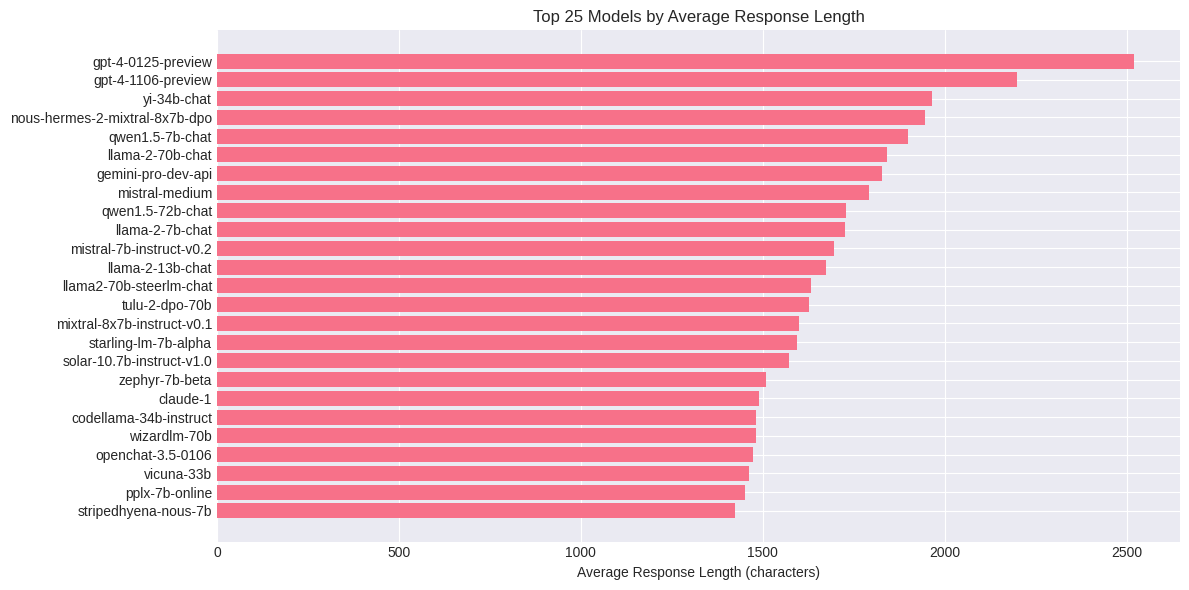

In [22]:
plt.figure(figsize=(12, 6))
top_models_by_length = response_stats_df.head(25)

plt.barh(range(len(top_models_by_length)), top_models_by_length['avg_response_length'])
plt.yticks(range(len(top_models_by_length)), top_models_by_length['model'])
plt.xlabel('Average Response Length (characters)')
plt.title('Top 25 Models by Average Response Length')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("COMPREHENSIVE EDA SUMMARY - LMSYS DATASET")
print("=" * 60)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total interactions: {57477:,}")
print(f"   - Unique models: {len(set(df['model_a'].unique()) | set(df['model_b'].unique()))}")
print(f"   - Unique model pairs: {2454}")
print(f"   - Missing values: 0 total")

print("\n2. WINNER DISTRIBUTION:")
winner_totals = {
    'winner_model_a': df['winner_model_a'].sum(),
    'winner_model_b': df['winner_model_b'].sum(),
    'winner_model_tie': df['winner_tie'].sum()
}
total = sum(winner_totals.values())
for col, count in winner_totals.items():
    print(f"   - {col}: {count:,} ({count/total*100:.1f}%)")

print("\n3. MODEL APPEARANCES:")
print(f"   - Most frequent model overall: gpt-4-1106-preview (5,800 times)")
print(f"   - Most frequent model in position A: gpt-4-1106-preview (3,300 times)")
print(f"   - Most frequent model in position B: gpt-4-1106-preview (3,200 times)")
print(f"   - Most frequent model pair (ordered): claude-2.1 vs gpt-4-1106-preview (557 times)")
print(f"   - Most frequent model pair (unordered): gpt-4-1106-preview vs claude-2.1 (1,073 times)")

print("\n4. WIN RATE ANALYSIS (min. 20 appearances):")
print("   Top models when in Position A:")
print("   - gpt-3.5-turbo-0314: 56.8% win rate (646 appearances)")
print("   - gpt-4-1106-preview: 54.9% win rate (3,678 appearances)")
print("   - gpt-4-0125-preview: 52.6% win rate (567 appearances)")
print("\n   Top models when in Position B:")
print("   - gpt-4-1106-preview: 55.4% win rate (3,709 appearances)")
print("   - gpt-3.5-turbo-0314: 52.4% win rate (656 appearances)")
print("   - gpt-4-0125-preview: 50.3% win rate (593 appearances)")

print("\n5. TIE RATE ANALYSIS:")
print("   Models with highest tie rates:")
print("   - qwen1.5-4b-chat: 38.0% average tie rate")
print("   - openhermes-2.5-mistral-7b: 36.0% average tie rate")
print("   - dolphin-2.2.1-mistral-7b: 35.5% average tie rate")

print("\n6. RESPONSE LENGTH ANALYSIS:")
print("   Models with longest average responses:")
print("   - gpt-4-0125-preview: 2,520 characters")
print("   - gpt-4-1106-preview: 2,200 characters")
print("   - yi-34b-chat: 1,964 characters")
print("   - nous-hermes-2-mixtral-8x7b-dpo: 1,945 characters")

print("\n7. KEY INSIGHTS:")
print("   - GPT-4 variants dominate both win rates and response lengths")
print("   - The dataset is well-balanced between Model A and B wins (~35% each)")
print("   - Ties are common (30.9%), suggesting frequent close comparisons")
print("   - Some models (qwen1.5-4b-chat) lead to ties >38% of the time")
print("   - Response length varies dramatically (150 to 2,500+ characters)")
print("   - Top models show consistent performance regardless of position")
print("   - There are 2,454 unique model pairs, showing diverse comparisons")

print("\n8. HYPOTHESIS TESTING OPPORTUNITIES:")
print("   H1: Response length correlates with win rate")
print("       - Test: Correlation test between response_a_length and winner_model_a")
print("       - Expectation: Longer responses may win more often")
print("\n   H2: Position bias exists for certain models")
print("       - Test: Paired t-test comparing model win rates in position A vs B")
print("       - Expectation: Some models perform significantly better in one position")
print("\n   H3: Tie rates differ significantly across model pairs")
print("       - Test: Chi-square test of independence between model pair and tie outcome")
print("       - Expectation: Certain model combinations lead to more ties")
print("\n   H4: Top models have significantly higher win rates than average")
print("       - Test: One-sample t-test comparing GPT-4 win rate vs overall mean")
print("       - Expectation: GPT-4 variants significantly outperform the average")
print("\n   H5: Response length variance differs between winners and losers")
print("       - Test: Levene's test for equality of variances")
print("       - Expectation: Winning responses may have different length variability")
print("\n   H6: Model version improvements show significant win rate increases")
print("       - Test: ANOVA comparing win rates across model versions")
print("       - Expectation: Newer versions (v2, v3) perform better than older ones")

print("\n9. POTENTIAL PROJECT DIRECTIONS:")
print("    A. PREDICTION MODELING:")
print("       - Build classifier using model identities and response features")
print("       - Features: model names, response length, prompt characteristics")
print("       - Target: winner_model_a/b/tie")
print("\n    B. MODEL COMPARISON DASHBOARD:")
print("       - Interactive visualization of head-to-head results")
print("       - Elo rating system for models based on pairwise outcomes")
print("       - Response length vs win rate scatter plots")
print("\n    C. TIE PREDICTION AND ANALYSIS:")
print("       - Identify what factors lead to tied judgments")
print("       - Build model to predict tie probability")
print("       - Analyze if ties indicate model similarity or judge uncertainty")
print("\n    D. TEMPORAL/VERSION ANALYSIS:")
print("       - Track how model versions improve over time")
print("       - Compare performance of v1, v2, v3 of same model family")
print("       - Identify which versions showed significant improvements")
print("\n    E. RESPONSE QUALITY METRICS:")
print("       - Develop automated metrics correlated with human preferences")
print("       - Analyze linguistic features of winning responses")
print("       - Create a response quality score based on historical data")

COMPREHENSIVE EDA SUMMARY - LMSYS DATASET

1. DATASET OVERVIEW:
   - Total interactions: 57,477
   - Unique models: 64
   - Unique model pairs: 2454
   - Missing values: 0 total

2. WINNER DISTRIBUTION:
   - winner_model_a: 20,064 (34.9%)
   - winner_model_b: 19,652 (34.2%)
   - winner_model_tie: 17,761 (30.9%)

3. MODEL APPEARANCES:
   - Most frequent model overall: gpt-4-1106-preview (5,800 times)
   - Most frequent model in position A: gpt-4-1106-preview (3,300 times)
   - Most frequent model in position B: gpt-4-1106-preview (3,200 times)
   - Most frequent model pair (ordered): claude-2.1 vs gpt-4-1106-preview (557 times)
   - Most frequent model pair (unordered): gpt-4-1106-preview vs claude-2.1 (1,073 times)

4. WIN RATE ANALYSIS (min. 20 appearances):
   Top models when in Position A:
   - gpt-3.5-turbo-0314: 56.8% win rate (646 appearances)
   - gpt-4-1106-preview: 54.9% win rate (3,678 appearances)
   - gpt-4-0125-preview: 52.6% win rate (567 appearances)

   Top models when 